# **Part 0: Project Presentation**

## Context

This project focuses on sentiment analysis of financial news using the *auditor_sentiment* dataset (Hugging Face). The objective is to automatically classify a financial news headline or sentence into one of three sentiments: negative, neutral, or positive.

## Problem Statement

Through this project, we aimed to propose unsupervised AI models capable of classifying financial news headlines in order to estimate their impact on the financial market.  
This could help feed real-time market indicators, quickly filter large volumes of news, and support decision-making.

## Data

- Source: `Tydyannes69/auditor_sentiment` (Hugging Face)
- ~4,840 sentences after duplicate removal
- 3 classes: negative (0), neutral (1), positive (2)
- Strong imbalance: the “neutral” class is largely dominant (around 60%)

## Methodology

We compare several families of models, from the simplest to the most complex:

1. **Classical models v1** (Part 2): TF-IDF and SVD reduction, then logistic regression, naive Bayes (Gaussian, Bernoulli), decision tree, and random forest.
2. **Classical models v2** (Part 3): same algorithms but with improved sentence preprocessing to include negation.
3. **Sentence-BERT + classifier** (Part 4): pre-trained semantic embeddings and logistic regression.
4. **DistilBERT fine-tuning** (Part 5): full adaptation of a transformer to the dataset.
5. **Final comparison** (Part 6): graphical synthesis of the models according to precision, time, MSE, and cost.

## Evaluation Metrics

To compare these models, we will use the macro-F1 score. We cannot rely on accuracy alone, because a model always predicting “neutral” would achieve 60% accuracy. The macro-F1 score computes the F1 independently for each class, then takes the unweighted average. Each class therefore has the same importance regardless of its size.  
We will also compare training time and inference time.  
We will also examine the mean squared error (MSE).  
Finally, we will provide cost estimations for the models.

In [ ]:
# === Library imports (consolidated for the whole notebook) ===

# Standard library
import os
import re
import time

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.patches import Patch
import psutil

# NLP
import nltk
from nltk.corpus import stopwords
import spacy
#python -m spacy download en_core_web_sm

# Datasets / Profiling
from datasets import load_dataset, Dataset
from ydata_profiling import ProfileReport

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
)

# Transformers / Sentence-BERT
from sentence_transformers import SentenceTransformer
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import evaluate
import torch


C:\Users\jerem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\jerem\AppData\Local\Temp\ipykernel_29864\3275778514.py:23: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


# **Part 1 : Data Preperation**

## **1.1 - Import Data Set**

We first found and imported our auditor_sentiment data set from hugging face by connecting to our account with a token.

In [2]:
ds = load_dataset("Tydyannes69/auditor_sentiment")

In [3]:
df_train = ds["train"].to_pandas()
df_test = ds["test"].to_pandas()

print(df_train.head())
print(df_test.columns)

                                            sentence  label
0  Altia 's operating profit jumped to EUR 47 mil...      2
1  The agreement was signed with Biohit Healthcar...      2
2  Kesko pursues a strategy of healthy , focused ...      2
3  Vaisala , headquartered in Helsinki in Finland...      1
4  Also , a six-year historic analysis is provide...      1
Index(['sentence', 'label'], dtype='object')


In [4]:
df_combined = pd.concat([df_train, df_test], ignore_index=True)

We use ydata to produce a HTML file which contains descriptives statistics from our dataset.

In [5]:
profile = ProfileReport(df_combined, title="Profiling Dataset", explorative=True)
profile.to_file("Statistiques descriptives.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 666.40it/s]


With ydata, we observed that there are duplicates, so we will remove them.

In [6]:
df_combined = df_combined.drop_duplicates()

Here, we split the dataset with 80% of the data for training and 20% of the data to test the accuracy of our model.

In [7]:
df_train_original, df_test_original = train_test_split(df_combined, test_size=0.2,stratify=df_combined["label"],random_state=42)
# df_train_original.to_csv("train.csv", index=False)
# df_test_original.to_csv("test.csv", index=False)

## **1.2 - Descriptive Statistics**

In [8]:
print(f"Number of rows: {df_combined.shape[0]}")
print(f"Number of columns: {df_combined.shape[1]}")
print(f"Names of the Columns: {df_combined.columns.tolist()}")

Number of rows: 4840
Number of columns: 2
Names of the Columns: ['sentence', 'label']


### Transformation of the variable "label"

In [9]:
df_combined["label_num"] = df_combined["label"].map({
    0: "negative",
    1: "neutral",
    2: "positive"
})

C:\Users\jerem\AppData\Local\Temp\ipykernel_29864\1716255520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined["label_num"] = df_combined["label"].map({


### Description of the variable "label"

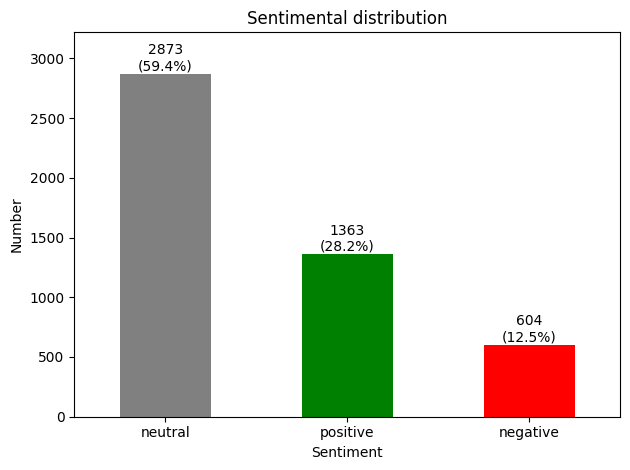

In [10]:
counts = df_combined["label_num"].value_counts()
total = counts.sum()

ax = counts.plot(kind="bar", color=["grey", "green", "red"])
plt.title("Sentimental distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number")
plt.xticks(rotation=0)

for i, v in enumerate(counts):
    pct = v / total * 100
    ax.text(i, v, f"{v}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.ylim(0, counts.max() * 1.12)
plt.tight_layout()
plt.show()

## **1.3 - Data Cleaning**

### Text Cleaning

We used the libraries NLTK and SpaCy for text processing and analysis. SpaCy (en_core_web_sm) facilitates advanced tasks such as lemmatization and syntactic analysis. Common words (stopwords) are removed in order to focus on and analyze the most meaningful terms.

Before converting raw text into usable data with CountVectorizer and TfidfVectorizer, it is necessary to clean the data. We therefore decided to standardize the text by converting it to lowercase, then removing special characters, numbers, and extra spaces.

In [11]:
nltk.download('stopwords')

# Stopwords anglais
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # suppression des stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jerem\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Lemmatize Text

Lemmatization reduces each word to its base form (e.g., “studying” becomes “study”). This reduces the complexity of the vocabulary while preserving the meaning of sentences.

We chose to lemmatize the textual variable "sentence", as it contains longer and meaningful sentences that are important for predicting our target variable.

We chose lemmatization rather than stemming because lemmatization preserves the meaning of words.

Finally, we applied lemmatization before vectorization to prevent the model from considering words like “study”, “studies”, and “studying” as three different terms. By doing so, we reduce computation time and improve the relevance of the results.

In [12]:
# Charger modèle anglais
nlp = spacy.load("en_core_web_sm")

def lemmatize_text(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_punct]
    return " ".join(tokens)

We proceed to data cleaning and lemmatizing our text on train et test dataset.

In [13]:
df_train = df_train_original.copy()
df_test = df_test_original.copy()

df_train["sentence_clean"] = df_train_original["sentence"].apply(clean_text).apply(lemmatize_text)
df_test["sentence_clean"] = df_test_original["sentence"].apply(clean_text).apply(lemmatize_text)

Here, there is some examples of the output.

In [14]:
df_train.head()

,sentence,label,sentence_clean
883,Currently Alfred A Palmberg is putting the fin...,1,currently alfred palmberg put finishing touch ...
3204,Finnish Rautaruukki has been awarded a contrac...,2,finnish rautaruukki award contract supply inst...
2422,Finnish Bore that is owned by the Rettig famil...,2,finnish bore own rettig family grown recently ...
4831,YIT 's Baltic sales in the first three quarter...,0,yit baltic sale first three quarter total mill...
3371,HKScan is one of the leading food companies in...,1,hkscan one lead food company northern europe h...


### Vectorizing Text

Vectorization is the step that transforms textual sentences into numerical representations that machine learning algorithms can process. The choice of method largely determines the final performance.

In [15]:
tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(df_train["sentence_clean"])
X_test_tfidf = tfidf_vectorizer.transform(df_test["sentence_clean"])

vocab = tfidf_vectorizer.get_feature_names_out()

print(f"Vocabulary size : {len(vocab):,}")
print(f"X_train shape   : {X_train_tfidf.shape}")
print(f"X_test  shape   : {X_test_tfidf.shape}")
print(f"Sparsity (train): {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4%}")
print(f"Avg non-zero features / doc : {X_train_tfidf.nnz / X_train_tfidf.shape[0]:.1f}")

print("\nVocabulary sample (first 20) :")
print(vocab[:20])

Vocabulary size : 6,982
X_train shape   : (3872, 6982)
X_test  shape   : (968, 6982)
Sparsity (train): 99.8399%
Avg non-zero features / doc : 11.2

Vocabulary sample (first 20) :
['aaland' 'aalborg' 'aalto' 'aaron' 'aava' 'aazhang' 'ab' 'abb' 'abbott'
 'abc' 'aberration' 'abidjan' 'ability' 'able' 'abloy' 'abn'
 'abovementione' 'abp' 'abroad' 'absentee']


### Dimension Reduction

n=  50 | variance=18.32% | macro-F1=0.4886
n= 100 | variance=26.36% | macro-F1=0.5536
n= 150 | variance=32.61% | macro-F1=0.5724
n= 200 | variance=37.80% | macro-F1=0.5837
n= 300 | variance=46.23% | macro-F1=0.6090
n= 500 | variance=58.44% | macro-F1=0.6383
n= 800 | variance=70.71% | macro-F1=0.6349


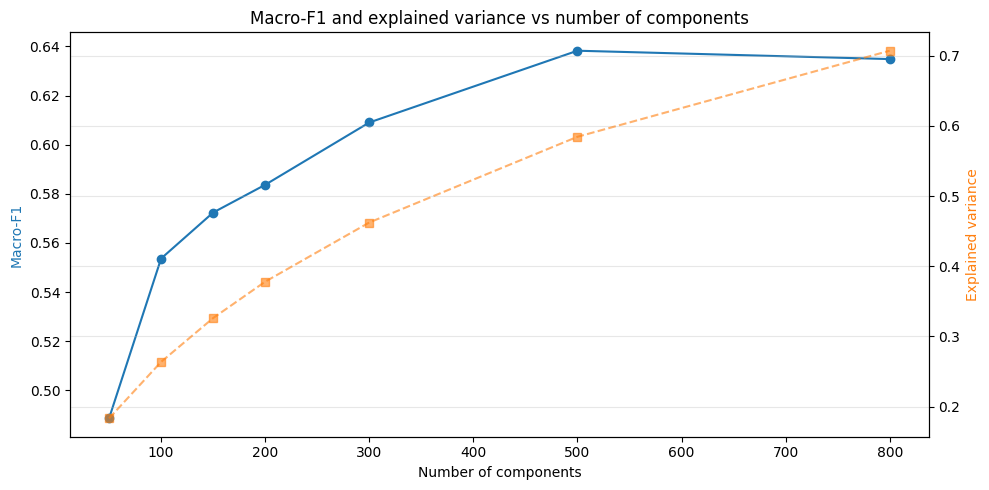

In [16]:
y_train = df_train["label"]
y_test = df_test["label"]

results = []
for n in [50, 100, 150, 200, 300, 500, 800]:
    svd = TruncatedSVD(n_components=n, random_state=42)
    X_tr = svd.fit_transform(X_train_tfidf)
    X_te = svd.transform(X_test_tfidf)
    
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_train)
    pred = clf.predict(X_te)
    
    f1 = f1_score(y_test, pred, average="macro")
    var = svd.explained_variance_ratio_.sum()
    results.append((n, var, f1))
    print(f"n={n:4d} | variance={var:.2%} | macro-F1={f1:.4f}")

# Plot performance vs n_components
ns, vars_, f1s = zip(*results)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(ns, f1s, "o-", color="tab:blue", label="Macro-F1")
ax1.set_xlabel("Number of components")
ax1.set_ylabel("Macro-F1", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(ns, vars_, "s--", color="tab:orange", alpha=0.6, label="Explained variance")
ax2.set_ylabel("Explained variance", color="tab:orange")
plt.title("Macro-F1 and explained variance vs number of components")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

On the graph, we can see that the Macro-F1 score reaches a plateau starting from 500 dimensions.

In [17]:
# Réduction de dimension
svd = TruncatedSVD(n_components=500, random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)
print(f"Variance expliquée : {svd.explained_variance_ratio_.sum():.2%}")
print(X_train_svd.shape)
print(X_test_svd.shape)

Variance expliquée : 58.44%
(3872, 500)
(968, 500)


# **Part 2 : Classifier**

## **2.1 - Logistic Regression**

In [18]:
# Dictionnaire global pour collecter les resultats de chaque modele.
results_collected = {}

In [19]:
y_train = df_train["label"]
y_test = df_test["label"]

process = psutil.Process(os.getpid())
cpu_before_fit = process.cpu_times()

clf = LogisticRegression(max_iter=1000, random_state=42)
start_fit = time.perf_counter()
clf.fit(X_train_svd, y_train)
end_fit = time.perf_counter()

cpu_after_fit = process.cpu_times()

fit_time = end_fit - start_fit
fit_cpu_user = cpu_after_fit.user - cpu_before_fit.user
fit_cpu_sys  = cpu_after_fit.system - cpu_before_fit.system

cpu_before_pred = process.cpu_times()

start_pred = time.perf_counter()
y_pred = clf.predict(X_test_svd)
end_pred = time.perf_counter()

cpu_after_pred = process.cpu_times()

pred_time = end_pred - start_pred
pred_cpu_user = cpu_after_pred.user - cpu_before_pred.user
pred_cpu_sys  = cpu_after_pred.system - cpu_before_pred.system

print("Classification : ")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred))

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print("\nErrors : ")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPerformance :")
print(f"Training     : {fit_time:.4f} s "
      f"(CPU user {fit_cpu_user:.4f}s | sys {fit_cpu_sys:.4f}s)")
print(f"Inference    : {pred_time:.4f} s "
      f"(CPU user {pred_cpu_user:.4f}s | sys {pred_cpu_sys:.4f}s)")
print(f"Total : {fit_time + pred_time:.4f} s ")

results_collected["LR v1"] = {
    "macro_f1":  classification_report(y_test, y_pred, output_dict=True)["macro avg"]["f1-score"],
    "fit_time":  fit_time,
    "pred_time": pred_time,
    "mse":       mse,
    "gpu":       False,
}

Classification : 
Accuracy : 0.7376
              precision    recall  f1-score   support

           0       0.81      0.40      0.53       121
           1       0.73      0.95      0.83       575
           2       0.74      0.44      0.56       272

    accuracy                           0.74       968
   macro avg       0.76      0.60      0.64       968
weighted avg       0.74      0.74      0.71       968

Confusion matrix :
[[ 48  56  17]
 [  5 545  25]
 [  6 145 121]]

Errors : 
MSE  : 0.3337
RMSE : 0.5776
MAE  : 0.2862

Performance :
Training     : 0.0656 s (CPU user 0.3438s | sys 0.2031s)
Inference    : 0.0006 s (CPU user 0.0000s | sys 0.0000s)
Total : 0.0662 s 


## **2.2 - Gaussian Classifier**

In [20]:
y_train = df_train["label"]
y_test = df_test["label"]

process = psutil.Process(os.getpid())
cpu_before_fit = process.cpu_times()

gnb = GaussianNB()
start_fit = time.perf_counter()
gnb.fit(X_train_svd, y_train)
end_fit = time.perf_counter()

cpu_after_fit = process.cpu_times()

fit_time = end_fit - start_fit
fit_cpu_user = cpu_after_fit.user - cpu_before_fit.user
fit_cpu_sys  = cpu_after_fit.system - cpu_before_fit.system

cpu_before_pred = process.cpu_times()

start_pred = time.perf_counter()
y_pred_gnb = gnb.predict(X_test_svd)
end_pred = time.perf_counter()

cpu_after_pred = process.cpu_times()

pred_time = end_pred - start_pred
pred_cpu_user = cpu_after_pred.user - cpu_before_pred.user
pred_cpu_sys  = cpu_after_pred.system - cpu_before_pred.system

print("Classification : ")
print(f"Accuracy : {accuracy_score(y_test, y_pred_gnb):.4f}")
print(classification_report(y_test, y_pred_gnb))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred_gnb))

mse  = mean_squared_error(y_test, y_pred_gnb)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_gnb)

print("\nErrors : ")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPerformance :")
print(f"Training     : {fit_time:.4f} s "
      f"(CPU user {fit_cpu_user:.4f}s | sys {fit_cpu_sys:.4f}s)")
print(f"Inference    : {pred_time:.4f} s "
      f"(CPU user {pred_cpu_user:.4f}s | sys {pred_cpu_sys:.4f}s)")
print(f"Total : {fit_time + pred_time:.4f} s ")

results_collected["GNB v1"] = {
    "macro_f1":  classification_report(y_test, y_pred_gnb, output_dict=True)["macro avg"]["f1-score"],
    "fit_time":  fit_time,
    "pred_time": pred_time,
    "mse":       mse,
    "gpu":       False,
}

Classification : 
Accuracy : 0.4318
              precision    recall  f1-score   support

           0       0.18      0.63      0.28       121
           1       0.67      0.50      0.57       575
           2       0.50      0.21      0.29       272

    accuracy                           0.43       968
   macro avg       0.45      0.44      0.38       968
weighted avg       0.56      0.43      0.46       968

Confusion matrix :
[[ 76  35  10]
 [242 286  47]
 [112 104  56]]

Errors : 
MSE  : 0.9463
RMSE : 0.9728
MAE  : 0.6942

Performance :
Training     : 0.0167 s (CPU user 0.0156s | sys 0.0000s)
Inference    : 0.0028 s (CPU user 0.0000s | sys 0.0000s)
Total : 0.0196 s 


## **2.3 - Bernoulli Classifier**

In [21]:
# Transformer TF-IDF en binaire
X_train_bin = (X_train_tfidf > 0).astype(int)
X_test_bin = (X_test_tfidf > 0).astype(int)

process = psutil.Process(os.getpid())
cpu_before_fit = process.cpu_times()

bnb = BernoulliNB()
start_fit = time.perf_counter()
bnb.fit(X_train_bin, y_train)
end_fit = time.perf_counter()

cpu_after_fit = process.cpu_times()

fit_time = end_fit - start_fit
fit_cpu_user = cpu_after_fit.user - cpu_before_fit.user
fit_cpu_sys  = cpu_after_fit.system - cpu_before_fit.system

cpu_before_pred = process.cpu_times()

start_pred = time.perf_counter()
y_pred_bnb = bnb.predict(X_test_bin)
end_pred = time.perf_counter()

cpu_after_pred = process.cpu_times()

pred_time = end_pred - start_pred
pred_cpu_user = cpu_after_pred.user - cpu_before_pred.user
pred_cpu_sys  = cpu_after_pred.system - cpu_before_pred.system

print("Classification : ")
print(f"Accuracy : {accuracy_score(y_test, y_pred_bnb):.4f}")
print(classification_report(y_test, y_pred_bnb))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred_bnb))

mse  = mean_squared_error(y_test, y_pred_bnb)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_bnb)

print("\nErrors : ")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPerformance :")
print(f"Training     : {fit_time:.4f} s "
      f"(CPU user {fit_cpu_user:.4f}s | sys {fit_cpu_sys:.4f}s)")
print(f"Inference    : {pred_time:.4f} s "
      f"(CPU user {pred_cpu_user:.4f}s | sys {pred_cpu_sys:.4f}s)")
print(f"Total : {fit_time + pred_time:.4f} s ")

results_collected["BNB v1"] = {
    "macro_f1":  classification_report(y_test, y_pred_bnb, output_dict=True)["macro avg"]["f1-score"],
    "fit_time":  fit_time,
    "pred_time": pred_time,
    "mse":       mse,
    "gpu":       False,
}

Classification : 
Accuracy : 0.6880
              precision    recall  f1-score   support

           0       0.89      0.07      0.12       121
           1       0.71      0.94      0.81       575
           2       0.58      0.43      0.50       272

    accuracy                           0.69       968
   macro avg       0.73      0.48      0.48       968
weighted avg       0.70      0.69      0.64       968

Confusion matrix :
[[  8  64  49]
 [  0 541  34]
 [  1 154 117]]

Errors : 
MSE  : 0.4669
RMSE : 0.6833
MAE  : 0.3636

Performance :
Training     : 0.0018 s (CPU user 0.0000s | sys 0.0000s)
Inference    : 0.0005 s (CPU user 0.0000s | sys 0.0000s)
Total : 0.0022 s 


## **2.4 - Decision Tree**

In [22]:
best_score = 0
best_params = None
best_model = None

# Ressources globales sur toute la recherche
process = psutil.Process(os.getpid())
cpu_before_search = process.cpu_times()
start_search = time.perf_counter()

n_combinations = 0

for max_depth in [5, 10, 15, 20, None]:
    for min_samples_split in [2, 5, 10, 20]:
        for min_samples_leaf in [1, 2, 4, 8]:
            for criterion in ["gini", "entropy"]:
                n_combinations += 1

                dt = DecisionTreeClassifier(
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    criterion=criterion,
                    random_state=42
                )

                dt.fit(X_train_svd, y_train)
                y_pred = dt.predict(X_test_svd)
                acc = accuracy_score(y_test, y_pred)

                if acc > best_score:
                    best_score = acc
                    best_params = {
                        "max_depth": max_depth,
                        "min_samples_split": min_samples_split,
                        "min_samples_leaf": min_samples_leaf,
                        "criterion": criterion
                    }
                    best_model = dt

end_search = time.perf_counter()
cpu_after_search = process.cpu_times()

search_time = end_search - start_search
search_cpu_user = cpu_after_search.user - cpu_before_search.user
search_cpu_sys  = cpu_after_search.system - cpu_before_search.system

print(f"Search: {n_combinations} combinations tested")
print(f"Meilleure accuracy : {best_score:.4f}")
print(f"Meilleurs params   : {best_params}")
print(f"Temps total recherche : {search_time:.2f} s "
      f"(CPU user {search_cpu_user:.2f}s | sys {search_cpu_sys:.2f}s)")
print(f"Temps moyen / combinaison : {search_time / n_combinations:.3f} s\n")

# --- Évaluation détaillée du meilleur modèle ---
cpu_before_fit = process.cpu_times()
start_fit = time.perf_counter()
best_model.fit(X_train_svd, y_train)
end_fit = time.perf_counter()
cpu_after_fit = process.cpu_times()

fit_time = end_fit - start_fit
fit_cpu_user = cpu_after_fit.user - cpu_before_fit.user
fit_cpu_sys  = cpu_after_fit.system - cpu_before_fit.system

cpu_before_pred = process.cpu_times()
start_pred = time.perf_counter()
y_pred_dt = best_model.predict(X_test_svd)
end_pred = time.perf_counter()
cpu_after_pred = process.cpu_times()

pred_time = end_pred - start_pred
pred_cpu_user = cpu_after_pred.user - cpu_before_pred.user
pred_cpu_sys  = cpu_after_pred.system - cpu_before_pred.system

print("Classification (best model) : ")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred_dt))

mse  = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_dt)

print("\nErrors : ")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPerformance (best model) :")
print(f"Training     : {fit_time:.4f} s "
      f"(CPU user {fit_cpu_user:.4f}s | sys {fit_cpu_sys:.4f}s)")
print(f"Inference    : {pred_time:.4f} s "
      f"(CPU user {pred_cpu_user:.4f}s | sys {pred_cpu_sys:.4f}s)")
print(f"Total : {fit_time + pred_time:.4f} s ")
print(f"\nTree  : depth={best_model.get_depth()}, "
      f"nb leaves={best_model.get_n_leaves()}")

results_collected["DT v1"] = {
    "macro_f1":  classification_report(y_test, y_pred_dt, output_dict=True)["macro avg"]["f1-score"],
    "fit_time":  fit_time,
    "pred_time": pred_time,
    "mse":       mse,
    "gpu":       False,
}

Search: 160 combinations tested
Meilleure accuracy : 0.6240
Meilleurs params   : {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'gini'}
Temps total recherche : 269.13 s (CPU user 262.27s | sys 3.55s)
Temps moyen / combinaison : 1.682 s

Classification (best model) : 
Accuracy : 0.6240
              precision    recall  f1-score   support

           0       0.41      0.10      0.16       121
           1       0.68      0.86      0.76       575
           2       0.47      0.36      0.41       272

    accuracy                           0.62       968
   macro avg       0.52      0.44      0.44       968
weighted avg       0.59      0.62      0.58       968

Confusion matrix :
[[ 12  71  38]
 [  8 494  73]
 [  9 165  98]]

Errors : 
MSE  : 0.5217
RMSE : 0.7223
MAE  : 0.4246

Performance (best model) :
Training     : 0.7900 s (CPU user 0.7812s | sys 0.0156s)
Inference    : 0.0006 s (CPU user 0.0000s | sys 0.0000s)
Total : 0.7907 s 

Tree  : depth=5, nb leav

## **2.5 - Random Forest**

In [23]:
best_score = 0
best_params = None
best_model = None

# Ressources globales sur toute la recherche
process = psutil.Process(os.getpid())
cpu_before_search = process.cpu_times()
start_search = time.perf_counter()

n_combinations = 0

for max_depth in [5, 10, 15, 20, None]:
    for min_samples_split in [2, 5, 10, 20]:
        for min_samples_leaf in [1, 2, 4, 8]:
            for criterion in ["gini", "entropy"]:
                n_combinations += 1

                dt = DecisionTreeClassifier(
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    criterion=criterion,
                    random_state=42
                )

                dt.fit(X_train_svd, y_train)
                y_pred = dt.predict(X_test_svd)
                acc = accuracy_score(y_test, y_pred)

                if acc > best_score:
                    best_score = acc
                    best_params = {
                        "max_depth": max_depth,
                        "min_samples_split": min_samples_split,
                        "min_samples_leaf": min_samples_leaf,
                        "criterion": criterion
                    }
                    best_model = dt

end_search = time.perf_counter()
cpu_after_search = process.cpu_times()

search_time = end_search - start_search
search_cpu_user = cpu_after_search.user - cpu_before_search.user
search_cpu_sys  = cpu_after_search.system - cpu_before_search.system

print(f"Search: {n_combinations} combinations tested")
print(f"Meilleure accuracy : {best_score:.4f}")
print(f"Meilleurs params   : {best_params}")
print(f"Temps total recherche : {search_time:.2f} s "
      f"(CPU user {search_cpu_user:.2f}s | sys {search_cpu_sys:.2f}s)")
print(f"Temps moyen / combinaison : {search_time / n_combinations:.3f} s\n")

# --- Évaluation détaillée du meilleur modèle ---
cpu_before_fit = process.cpu_times()
start_fit = time.perf_counter()
best_model.fit(X_train_svd, y_train)
end_fit = time.perf_counter()
cpu_after_fit = process.cpu_times()

fit_time = end_fit - start_fit
fit_cpu_user = cpu_after_fit.user - cpu_before_fit.user
fit_cpu_sys  = cpu_after_fit.system - cpu_before_fit.system

cpu_before_pred = process.cpu_times()
start_pred = time.perf_counter()
y_pred_dt = best_model.predict(X_test_svd)
end_pred = time.perf_counter()
cpu_after_pred = process.cpu_times()

pred_time = end_pred - start_pred
pred_cpu_user = cpu_after_pred.user - cpu_before_pred.user
pred_cpu_sys  = cpu_after_pred.system - cpu_before_pred.system

print("Classification (best model) : ")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred_dt))

mse  = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_dt)

print("\nErrors : ")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPerformance (best model) :")
print(f"Training     : {fit_time:.4f} s "
      f"(CPU user {fit_cpu_user:.4f}s | sys {fit_cpu_sys:.4f}s)")
print(f"Inference    : {pred_time:.4f} s "
      f"(CPU user {pred_cpu_user:.4f}s | sys {pred_cpu_sys:.4f}s)")
print(f"Total : {fit_time + pred_time:.4f} s ")
print(f"\nTree  : depth={best_model.get_depth()}, "
      f"nb leaves={best_model.get_n_leaves()}")

results_collected["RF v1"] = {
    "macro_f1":  classification_report(y_test, y_pred_dt, output_dict=True)["macro avg"]["f1-score"],
    "fit_time":  fit_time,
    "pred_time": pred_time,
    "mse":       mse,
    "gpu":       False,
}

Search: 160 combinations tested
Meilleure accuracy : 0.6240
Meilleurs params   : {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 4, 'criterion': 'gini'}
Temps total recherche : 276.04 s (CPU user 268.61s | sys 3.31s)
Temps moyen / combinaison : 1.725 s

Classification (best model) : 
Accuracy : 0.6240
              precision    recall  f1-score   support

           0       0.41      0.10      0.16       121
           1       0.68      0.86      0.76       575
           2       0.47      0.36      0.41       272

    accuracy                           0.62       968
   macro avg       0.52      0.44      0.44       968
weighted avg       0.59      0.62      0.58       968

Confusion matrix :
[[ 12  71  38]
 [  8 494  73]
 [  9 165  98]]

Errors : 
MSE  : 0.5217
RMSE : 0.7223
MAE  : 0.4246

Performance (best model) :
Training     : 0.7986 s (CPU user 0.7656s | sys 0.0000s)
Inference    : 0.0008 s (CPU user 0.0000s | sys 0.0000s)
Total : 0.7994 s 

Tree  : depth=5, nb leav

# **Part 3 : Classifier 2.0**

## **3.1 - Data Cleaning**

Dans cette partie, on supprime tous les stopwords sauf les negations.

### Text Cleaning

In [24]:
nltk.download('stopwords')

# Stopwords anglais
stop_words = set(stopwords.words('english'))

negations = {"not", "no", "never", "none", "didn't", "nobody", "nothing", "nowhere", "neither", "nor"}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = text.split()
    
    # garder les négations même si elles sont dans stopwords
    tokens = [word for word in tokens if (word not in stop_words or word in negations)]
    
    return " ".join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jerem\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Lemmatize Text

In [25]:
nlp = spacy.load("en_core_web_sm")

def lemmatize_text(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_punct]
    return " ".join(tokens)

In [26]:
df_train["sentence_clean"] = df_train_original["sentence"].apply(clean_text).apply(lemmatize_text)
df_test["sentence_clean"] = df_test_original["sentence"].apply(clean_text).apply(lemmatize_text)

In [27]:
count = 0

for text in df_train["sentence_clean"]:
    words = text.split()
    count += sum(1 for w in words if w in negations)

print("Number of negations :", count)

Number of negations : 133


### Vectorizing Text

In [28]:
tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(df_train["sentence_clean"])
X_test_tfidf = tfidf_vectorizer.transform(df_test["sentence_clean"])


### Dimension Reduction

n=  50 | variance=18.40% | macro-F1=0.4870
n= 100 | variance=26.45% | macro-F1=0.5553
n= 150 | variance=32.70% | macro-F1=0.5762
n= 200 | variance=37.89% | macro-F1=0.5809
n= 300 | variance=46.31% | macro-F1=0.6166
n= 500 | variance=58.52% | macro-F1=0.6396
n= 800 | variance=70.77% | macro-F1=0.6384


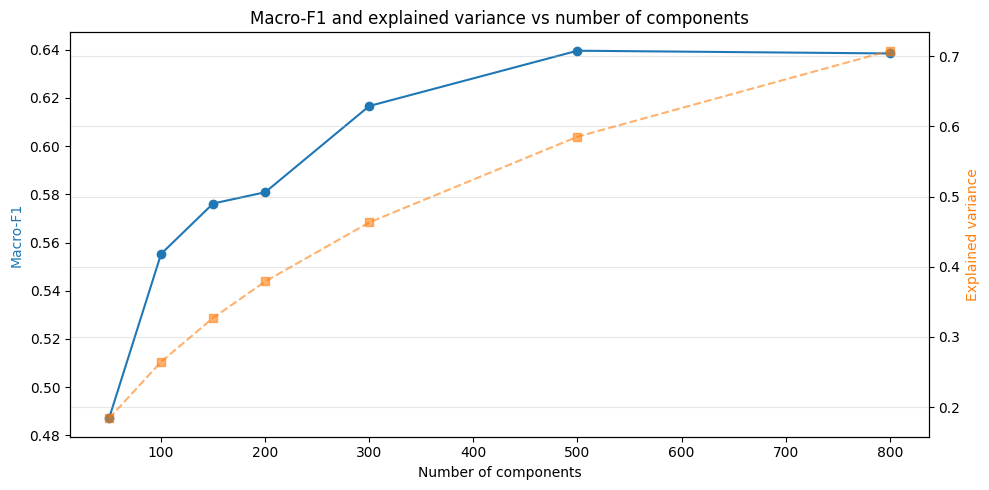

In [29]:
y_train = df_train["label"]
y_test = df_test["label"]

results = []
for n in [50, 100, 150, 200, 300, 500, 800]:
    svd = TruncatedSVD(n_components=n, random_state=42)
    X_tr = svd.fit_transform(X_train_tfidf)
    X_te = svd.transform(X_test_tfidf)
    
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_train)
    pred = clf.predict(X_te)
    
    f1 = f1_score(y_test, pred, average="macro")
    var = svd.explained_variance_ratio_.sum()
    results.append((n, var, f1))
    print(f"n={n:4d} | variance={var:.2%} | macro-F1={f1:.4f}")

# Plot performance vs n_components
ns, vars_, f1s = zip(*results)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(ns, f1s, "o-", color="tab:blue", label="Macro-F1")
ax1.set_xlabel("Number of components")
ax1.set_ylabel("Macro-F1", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(ns, vars_, "s--", color="tab:orange", alpha=0.6, label="Explained variance")
ax2.set_ylabel("Explained variance", color="tab:orange")
plt.title("Macro-F1 and explained variance vs number of components")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Réduction de dimension
svd = TruncatedSVD(n_components=500, random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

print(X_train_svd.shape)
print(X_test_svd.shape)

(3872, 500)
(968, 500)


## **3.2 - Logistic Regression 2.0**

In [31]:
y_train = df_train["label"]
y_test = df_test["label"]

process = psutil.Process(os.getpid())
cpu_before_fit = process.cpu_times()

clf = LogisticRegression(max_iter=1000, random_state=42)
start_fit = time.perf_counter()
clf.fit(X_train_svd, y_train)
end_fit = time.perf_counter()

cpu_after_fit = process.cpu_times()

fit_time = end_fit - start_fit
fit_cpu_user = cpu_after_fit.user - cpu_before_fit.user
fit_cpu_sys  = cpu_after_fit.system - cpu_before_fit.system

cpu_before_pred = process.cpu_times()

start_pred = time.perf_counter()
y_pred = clf.predict(X_test_svd)
end_pred = time.perf_counter()

cpu_after_pred = process.cpu_times()

pred_time = end_pred - start_pred
pred_cpu_user = cpu_after_pred.user - cpu_before_pred.user
pred_cpu_sys  = cpu_after_pred.system - cpu_before_pred.system

print("Classification : ")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred))

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print("\nErrors : ")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPerformance :")
print(f"Training     : {fit_time:.4f} s "
      f"(CPU user {fit_cpu_user:.4f}s | sys {fit_cpu_sys:.4f}s)")
print(f"Inference    : {pred_time:.4f} s "
      f"(CPU user {pred_cpu_user:.4f}s | sys {pred_cpu_sys:.4f}s)")
print(f"Total : {fit_time + pred_time:.4f} s ")

# --- Collecte dynamique des resultats ---
results_collected["LR v2"] = {
    "macro_f1":  classification_report(y_test, y_pred, output_dict=True)["macro avg"]["f1-score"],
    "fit_time":  fit_time,
    "pred_time": pred_time,
    "mse":       mse,
    "gpu":       False,
}

Classification : 
Accuracy : 0.7386
              precision    recall  f1-score   support

           0       0.81      0.40      0.53       121
           1       0.73      0.95      0.83       575
           2       0.74      0.45      0.56       272

    accuracy                           0.74       968
   macro avg       0.76      0.60      0.64       968
weighted avg       0.75      0.74      0.71       968

Confusion matrix :
[[ 48  56  17]
 [  5 545  25]
 [  6 144 122]]

Errors : 
MSE  : 0.3326
RMSE : 0.5768
MAE  : 0.2851

Performance :
Training     : 0.0768 s (CPU user 0.6094s | sys 0.0938s)
Inference    : 0.0008 s (CPU user 0.0000s | sys 0.0000s)
Total : 0.0776 s 


## **3.4 - Gaussian Classifier 2.0**

In [32]:
process = psutil.Process(os.getpid())
cpu_before_fit = process.cpu_times()

gnb = GaussianNB()
start_fit = time.perf_counter()
gnb.fit(X_train_svd, y_train)
end_fit = time.perf_counter()

cpu_after_fit = process.cpu_times()

fit_time = end_fit - start_fit
fit_cpu_user = cpu_after_fit.user - cpu_before_fit.user
fit_cpu_sys  = cpu_after_fit.system - cpu_before_fit.system

cpu_before_pred = process.cpu_times()

start_pred = time.perf_counter()
y_pred_gnb = gnb.predict(X_test_svd)
end_pred = time.perf_counter()

cpu_after_pred = process.cpu_times()

pred_time = end_pred - start_pred
pred_cpu_user = cpu_after_pred.user - cpu_before_pred.user
pred_cpu_sys  = cpu_after_pred.system - cpu_before_pred.system

print("Classification : ")
print(f"Accuracy : {accuracy_score(y_test, y_pred_gnb):.4f}")
print(classification_report(y_test, y_pred_gnb))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred_gnb))

mse  = mean_squared_error(y_test, y_pred_gnb)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_gnb)

print("\nErrors : ")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPerformance :")
print(f"Training     : {fit_time:.4f} s "
      f"(CPU user {fit_cpu_user:.4f}s | sys {fit_cpu_sys:.4f}s)")
print(f"Inference    : {pred_time:.4f} s "
      f"(CPU user {pred_cpu_user:.4f}s | sys {pred_cpu_sys:.4f}s)")
print(f"Total : {fit_time + pred_time:.4f} s ")

# --- Collecte dynamique des resultats ---
results_collected["GNB v2"] = {
    "macro_f1":  classification_report(y_test, y_pred_gnb, output_dict=True)["macro avg"]["f1-score"],
    "fit_time":  fit_time,
    "pred_time": pred_time,
    "mse":       mse,
    "gpu":       False,
}

Classification : 
Accuracy : 0.4421
              precision    recall  f1-score   support

           0       0.18      0.66      0.29       121
           1       0.69      0.50      0.58       575
           2       0.53      0.22      0.31       272

    accuracy                           0.44       968
   macro avg       0.47      0.46      0.39       968
weighted avg       0.58      0.44      0.47       968

Confusion matrix :
[[ 80  34   7]
 [240 289  46]
 [118  95  59]]

Errors : 
MSE  : 0.9452
RMSE : 0.9722
MAE  : 0.6870

Performance :
Training     : 0.0200 s (CPU user 0.0156s | sys 0.0000s)
Inference    : 0.0036 s (CPU user 0.0000s | sys 0.0000s)
Total : 0.0236 s 


## **3.5 - Bernoulli Classifier 2.0**

In [33]:
# Transformer TF-IDF en binaire
X_train_bin = (X_train_tfidf > 0).astype(int)
X_test_bin = (X_test_tfidf > 0).astype(int)

process = psutil.Process(os.getpid())
cpu_before_fit = process.cpu_times()

bnb = BernoulliNB()
start_fit = time.perf_counter()
bnb.fit(X_train_bin, y_train)
end_fit = time.perf_counter()

cpu_after_fit = process.cpu_times()

fit_time = end_fit - start_fit
fit_cpu_user = cpu_after_fit.user - cpu_before_fit.user
fit_cpu_sys  = cpu_after_fit.system - cpu_before_fit.system

cpu_before_pred = process.cpu_times()

start_pred = time.perf_counter()
y_pred_bnb = bnb.predict(X_test_bin)
end_pred = time.perf_counter()

cpu_after_pred = process.cpu_times()

pred_time = end_pred - start_pred
pred_cpu_user = cpu_after_pred.user - cpu_before_pred.user
pred_cpu_sys  = cpu_after_pred.system - cpu_before_pred.system

print("Classification : ")
print(f"Accuracy : {accuracy_score(y_test, y_pred_bnb):.4f}")
print(classification_report(y_test, y_pred_bnb))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred_bnb))

mse  = mean_squared_error(y_test, y_pred_bnb)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_bnb)

print("\nErrors : ")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPerformance :")
print(f"Training     : {fit_time:.4f} s "
      f"(CPU user {fit_cpu_user:.4f}s | sys {fit_cpu_sys:.4f}s)")
print(f"Inference    : {pred_time:.4f} s "
      f"(CPU user {pred_cpu_user:.4f}s | sys {pred_cpu_sys:.4f}s)")
print(f"Total : {fit_time + pred_time:.4f} s ")

# --- Collecte dynamique des resultats ---
results_collected["BNB v2"] = {
    "macro_f1":  classification_report(y_test, y_pred_bnb, output_dict=True)["macro avg"]["f1-score"],
    "fit_time":  fit_time,
    "pred_time": pred_time,
    "mse":       mse,
    "gpu":       False,
}

Classification : 
Accuracy : 0.6880
              precision    recall  f1-score   support

           0       0.89      0.07      0.12       121
           1       0.71      0.94      0.81       575
           2       0.58      0.43      0.50       272

    accuracy                           0.69       968
   macro avg       0.73      0.48      0.48       968
weighted avg       0.70      0.69      0.64       968

Confusion matrix :
[[  8  64  49]
 [  0 541  34]
 [  1 154 117]]

Errors : 
MSE  : 0.4669
RMSE : 0.6833
MAE  : 0.3636

Performance :
Training     : 0.0017 s (CPU user 0.0000s | sys 0.0000s)
Inference    : 0.0007 s (CPU user 0.0000s | sys 0.0000s)
Total : 0.0024 s 


## **3.6 - Decision Tree 2.0**

In [34]:
best_score = 0
best_params = None
best_model = None

process = psutil.Process(os.getpid())
cpu_before_search = process.cpu_times()
start_search = time.perf_counter()

n_combinations = 0

for max_depth in [5, 10, 15, 20, None]:
    for min_samples_split in [2, 5, 10, 20]:
        for min_samples_leaf in [1, 2, 4, 8]:
            for criterion in ["gini", "entropy"]:
                n_combinations += 1

                dt = DecisionTreeClassifier(
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    criterion=criterion,
                    random_state=42
                )

                dt.fit(X_train_svd, y_train)
                y_pred = dt.predict(X_test_svd)
                acc = accuracy_score(y_test, y_pred)

                if acc > best_score:
                    best_score = acc
                    best_params = {
                        "max_depth": max_depth,
                        "min_samples_split": min_samples_split,
                        "min_samples_leaf": min_samples_leaf,
                        "criterion": criterion
                    }
                    best_model = dt

end_search = time.perf_counter()
cpu_after_search = process.cpu_times()

search_time = end_search - start_search
search_cpu_user = cpu_after_search.user - cpu_before_search.user
search_cpu_sys  = cpu_after_search.system - cpu_before_search.system

print(f"Search: {n_combinations} combinations tested")
print(f"Meilleure accuracy : {best_score:.4f}")
print(f"Meilleurs params   : {best_params}")
print(f"Temps total recherche : {search_time:.2f} s "
      f"(CPU user {search_cpu_user:.2f}s | sys {search_cpu_sys:.2f}s)")
print(f"Temps moyen / combinaison : {search_time / n_combinations:.3f} s\n")

# --- Évaluation détaillée du meilleur modèle ---
cpu_before_fit = process.cpu_times()
start_fit = time.perf_counter()
best_model.fit(X_train_svd, y_train)
end_fit = time.perf_counter()
cpu_after_fit = process.cpu_times()

fit_time = end_fit - start_fit
fit_cpu_user = cpu_after_fit.user - cpu_before_fit.user
fit_cpu_sys  = cpu_after_fit.system - cpu_before_fit.system

cpu_before_pred = process.cpu_times()
start_pred = time.perf_counter()
y_pred_dt = best_model.predict(X_test_svd)
end_pred = time.perf_counter()
cpu_after_pred = process.cpu_times()

pred_time = end_pred - start_pred
pred_cpu_user = cpu_after_pred.user - cpu_before_pred.user
pred_cpu_sys  = cpu_after_pred.system - cpu_before_pred.system

print("Classification (best model) : ")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred_dt))

mse  = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_dt)

print("\nErrors : ")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPerformance (best model) :")
print(f"Training     : {fit_time:.4f} s "
      f"(CPU user {fit_cpu_user:.4f}s | sys {fit_cpu_sys:.4f}s)")
print(f"Inference    : {pred_time:.4f} s "
      f"(CPU user {pred_cpu_user:.4f}s | sys {pred_cpu_sys:.4f}s)")
print(f"Total : {fit_time + pred_time:.4f} s ")
print(f"\nTree  : depth={best_model.get_depth()}, "
      f"nb leaves={best_model.get_n_leaves()}")

# --- Collecte dynamique des resultats ---
results_collected["DT v2"] = {
    "macro_f1":  classification_report(y_test, y_pred_dt, output_dict=True)["macro avg"]["f1-score"],
    "fit_time":  fit_time,
    "pred_time": pred_time,
    "mse":       mse,
    "gpu":       False,
}

Search: 160 combinations tested
Meilleure accuracy : 0.6426
Meilleurs params   : {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}
Temps total recherche : 272.42 s (CPU user 265.55s | sys 3.56s)
Temps moyen / combinaison : 1.703 s

Classification (best model) : 
Accuracy : 0.6426
              precision    recall  f1-score   support

           0       0.31      0.07      0.11       121
           1       0.68      0.90      0.78       575
           2       0.53      0.35      0.42       272

    accuracy                           0.64       968
   macro avg       0.51      0.44      0.43       968
weighted avg       0.59      0.64      0.59       968

Confusion matrix :
[[  8  71  42]
 [ 13 520  42]
 [  5 173  94]]

Errors : 
MSE  : 0.5031
RMSE : 0.7093
MAE  : 0.4060

Performance (best model) :
Training     : 1.1880 s (CPU user 1.1875s | sys 0.0000s)
Inference    : 0.0009 s (CPU user 0.0000s | sys 0.0000s)
Total : 1.1888 s 

Tree  : depth=5, nb l

## **3.7 - Random Forest 2.0**

In [35]:
best_score = 0
best_params = None
best_model = None

process = psutil.Process(os.getpid())
cpu_before_search = process.cpu_times()
start_search = time.perf_counter()

n_combinations = 0

for n_estimators in [50, 100, 200]:
    for max_depth in [5, 10, 20, None]:
        for max_features in ["sqrt", "log2"]:
            for min_samples_split in [2, 5, 10]:
                for min_samples_leaf in [1, 2, 4]:
                    n_combinations += 1

                    rf = RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        max_features=max_features,
                        min_samples_split=min_samples_split,
                        min_samples_leaf=min_samples_leaf,
                        random_state=42,
                        n_jobs=-1
                    )

                    rf.fit(X_train_svd, y_train)
                    y_pred = rf.predict(X_test_svd)
                    acc = accuracy_score(y_test, y_pred)

                    if acc > best_score:
                        best_score = acc
                        best_params = {
                            "n_estimators": n_estimators,
                            "max_depth": max_depth,
                            "max_features": max_features,
                            "min_samples_split": min_samples_split,
                            "min_samples_leaf": min_samples_leaf
                        }
                        best_model = rf

end_search = time.perf_counter()
cpu_after_search = process.cpu_times()

search_time = end_search - start_search
search_cpu_user = cpu_after_search.user - cpu_before_search.user
search_cpu_sys  = cpu_after_search.system - cpu_before_search.system

print(f"Search: {n_combinations} combinations tested")
print(f"Meilleure accuracy : {best_score:.4f}")
print(f"Meilleurs params   : {best_params}")
print(f"Temps total recherche : {search_time:.2f} s "
      f"(CPU user {search_cpu_user:.2f}s | sys {search_cpu_sys:.2f}s)")
print(f"Temps moyen / combinaison : {search_time / n_combinations:.3f} s\n")

# --- Évaluation détaillée du meilleur modèle ---
cpu_before_fit = process.cpu_times()
start_fit = time.perf_counter()
best_model.fit(X_train_svd, y_train)
end_fit = time.perf_counter()
cpu_after_fit = process.cpu_times()

fit_time = end_fit - start_fit
fit_cpu_user = cpu_after_fit.user - cpu_before_fit.user
fit_cpu_sys  = cpu_after_fit.system - cpu_before_fit.system

cpu_before_pred = process.cpu_times()
start_pred = time.perf_counter()
y_pred_rf = best_model.predict(X_test_svd)
end_pred = time.perf_counter()
cpu_after_pred = process.cpu_times()

pred_time = end_pred - start_pred
pred_cpu_user = cpu_after_pred.user - cpu_before_pred.user
pred_cpu_sys  = cpu_after_pred.system - cpu_before_pred.system

print("Classification (best model) : ")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred_rf))

mse  = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_rf)

print("\nErrors : ")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPerformance (best model) :")
print(f"Training     : {fit_time:.4f} s "
      f"(CPU user {fit_cpu_user:.4f}s | sys {fit_cpu_sys:.4f}s)")
print(f"Inference    : {pred_time:.4f} s "
      f"(CPU user {pred_cpu_user:.4f}s | sys {pred_cpu_sys:.4f}s)")
print(f"Total : {fit_time + pred_time:.4f} s ")
print(f"\nForest: {best_model.n_estimators} trees, "
      f"average depth ≈ {np.mean([t.get_depth() for t in best_model.estimators_]):.1f}")

# --- Collecte dynamique des resultats ---
results_collected["RF v2"] = {
    "macro_f1":  classification_report(y_test, y_pred_rf, output_dict=True)["macro avg"]["f1-score"],
    "fit_time":  fit_time,
    "pred_time": pred_time,
    "mse":       mse,
    "gpu":       False,
}

Search: 216 combinations tested
Meilleure accuracy : 0.6787
Meilleurs params   : {'n_estimators': 200, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'min_samples_leaf': 1}
Temps total recherche : 87.35 s (CPU user 1066.73s | sys 86.19s)
Temps moyen / combinaison : 0.404 s

Classification (best model) : 
Accuracy : 0.6787
              precision    recall  f1-score   support

           0       0.79      0.16      0.26       121
           1       0.67      0.99      0.80       575
           2       0.76      0.25      0.38       272

    accuracy                           0.68       968
   macro avg       0.74      0.47      0.48       968
weighted avg       0.71      0.68      0.61       968

Confusion matrix :
[[ 19  84  18]
 [  2 569   4]
 [  3 200  69]]

Errors : 
MSE  : 0.3864
RMSE : 0.6216
MAE  : 0.3430

Performance (best model) :
Training     : 1.1061 s (CPU user 17.2969s | sys 0.6875s)
Inference    : 0.0403 s (CPU user 0.0312s | sys 0.0156s)
Total : 1.1463 s

# **Part 4 : Classifier 3.0**

DistilBERT reads each sentence and turns it into a vector. Unlike TF-IDF, which just counts words, DistilBERT actually looks at the whole sentence to understand what each word means in context, for instance, "bank" means something different in "river bank" and "investment bank". A special token, (CLS), captures the meaning of the entire sentence into a single vector, which we then feed into a classifier. The whole model is fine-tuned on our data so it learns to recognize financial sentiment specifically.

## **4.1 - Data Cleaning**

### Text Cleaning

In [36]:
def clean_text_bert(text):
    text = str(text).lower().strip()
    return text

In [37]:
df_train["sentence_clean"] = df_train_original["sentence"].apply(clean_text_bert)
df_test["sentence_clean"] = df_test_original["sentence"].apply(clean_text_bert)

## **4.2 - Sentence BERT Classifier**

In [38]:
y_train = df_train["label"]
y_test = df_test["label"]

process = psutil.Process(os.getpid())

# --- 1) Chargement du modèle d'embeddings ---
start_load = time.perf_counter()
embedder = SentenceTransformer("all-MiniLM-L6-v2")
end_load = time.perf_counter()
load_time = end_load - start_load

# --- 2) Encodage train ---
cpu_before_enc_train = process.cpu_times()
start_enc_train = time.perf_counter()
X_train_emb = embedder.encode(df_train["sentence"].tolist(), show_progress_bar=True)
end_enc_train = time.perf_counter()
cpu_after_enc_train = process.cpu_times()

enc_train_time = end_enc_train - start_enc_train
enc_train_cpu_user = cpu_after_enc_train.user - cpu_before_enc_train.user
enc_train_cpu_sys  = cpu_after_enc_train.system - cpu_before_enc_train.system

# --- 3) Encodage test ---
cpu_before_enc_test = process.cpu_times()
start_enc_test = time.perf_counter()
X_test_emb = embedder.encode(df_test["sentence"].tolist(), show_progress_bar=True)
end_enc_test = time.perf_counter()
cpu_after_enc_test = process.cpu_times()

enc_test_time = end_enc_test - start_enc_test
enc_test_cpu_user = cpu_after_enc_test.user - cpu_before_enc_test.user
enc_test_cpu_sys  = cpu_after_enc_test.system - cpu_before_enc_test.system

# --- 4) Entraînement classifieur ---
cpu_before_fit = process.cpu_times()
start_fit = time.perf_counter()
clf = LogisticRegression(max_iter=2000, random_state=42)
clf.fit(X_train_emb, y_train)
end_fit = time.perf_counter()
cpu_after_fit = process.cpu_times()

fit_time = end_fit - start_fit
fit_cpu_user = cpu_after_fit.user - cpu_before_fit.user
fit_cpu_sys  = cpu_after_fit.system - cpu_before_fit.system

# --- 5) Prédiction ---
cpu_before_pred = process.cpu_times()
start_pred = time.perf_counter()
y_pred = clf.predict(X_test_emb)
end_pred = time.perf_counter()
cpu_after_pred = process.cpu_times()

pred_time = end_pred - start_pred
pred_cpu_user = cpu_after_pred.user - cpu_before_pred.user
pred_cpu_sys  = cpu_after_pred.system - cpu_before_pred.system

# --- Résultats ---
print("Classification : ")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))
print("Confusion matrix :")
print(confusion_matrix(y_test, y_pred))

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print("\nErrors : ")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPerformance :")
print(f"Model loading      : {load_time:.4f} s")
print(f"Encodage train ({len(df_train)} ex.) : {enc_train_time:.4f} s "
      f"(CPU user {enc_train_cpu_user:.4f}s | sys {enc_train_cpu_sys:.4f}s)")
print(f"Encodage test  ({len(df_test)} ex.) : {enc_test_time:.4f} s "
      f"(CPU user {enc_test_cpu_user:.4f}s | sys {enc_test_cpu_sys:.4f}s)")
print(f"Classifier training: {fit_time:.4f} s "
      f"(CPU user {fit_cpu_user:.4f}s | sys {fit_cpu_sys:.4f}s)")
print(f"Classifier inference: {pred_time:.4f} s"
      f"(CPU user {pred_cpu_user:.4f}s | sys {pred_cpu_sys:.4f}s)")

print(f"Total : {load_time + enc_train_time + enc_test_time + fit_time + pred_time:.4f} s ")

print(f"\nDimension embeddings : {X_train_emb.shape[1]}")

# --- Collecte dynamique des resultats ---
results_collected["Sentence-BERT"] = {
    "macro_f1":  classification_report(y_test, y_pred, output_dict=True)["macro avg"]["f1-score"],
    "fit_time":  load_time + enc_train_time + enc_test_time + fit_time,
    "pred_time": pred_time,
    "mse":       mse,
    "gpu":       True,
}

Batches: 100%|██████████| 31/31 [00:01<00:00, 17.01it/s]


Classification : 
Accuracy : 0.7748
              precision    recall  f1-score   support

           0       0.78      0.66      0.72       121
           1       0.79      0.90      0.84       575
           2       0.73      0.56      0.63       272

    accuracy                           0.77       968
   macro avg       0.77      0.71      0.73       968
weighted avg       0.77      0.77      0.77       968

Confusion matrix :
[[ 80  29  12]
 [ 12 517  46]
 [ 10 109 153]]

Errors : 
MSE  : 0.2934
RMSE : 0.5417
MAE  : 0.2479

Performance :
Model loading      : 2.7125 s
Encodage train (3872 ex.) : 7.6183 s (CPU user 97.5469s | sys 6.1719s)
Encodage test  (968 ex.) : 1.8279 s (CPU user 23.7031s | sys 1.4062s)
Classifier training: 0.0823 s (CPU user 0.8906s | sys 0.3281s)
Classifier inference: 0.0010 s(CPU user 0.1719s | sys 0.0469s)
Total : 12.2420 s 

Dimension embeddings : 384


# **Part 5 : Classifier 4.0**

Fine-tuning means taking a model that has already learned the general structure of English from huge amounts of text, and continuing to train it on our specific task, classifying financial sentiment. Instead of starting from scratch, we keep all the linguistic knowledge BERT already has and just adjust it slightly so it gets better at our problem. We add a small classification layer on top of the [CLS] vector, and during training, both BERT and this new layer learn together.

## **5.2 - Data Cleaning**

### Text Cleaning

In [39]:
def clean_text_bert(text):
    text = str(text).lower().strip()
    return text

In [40]:
df_train["sentence_clean"] = df_train_original["sentence"].apply(clean_text_bert)
df_test["sentence_clean"] = df_test_original["sentence"].apply(clean_text_bert)

## **5.3 - Fine-Tuning BERT Transformers Classifier**

In [41]:
process = psutil.Process(os.getpid())

# --- 1) Préparer les données ---
train_ds = Dataset.from_pandas(df_train[["sentence", "label"]])
test_ds = Dataset.from_pandas(df_test[["sentence", "label"]])

# --- 2) Tokenizer + modèle ---
model_name = "distilbert-base-uncased"
start_load = time.perf_counter()
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)
load_time = time.perf_counter() - start_load

# --- 3) Tokenisation ---
def tokenize(batch):
    return tokenizer(batch["sentence"], truncation=True)

start_tok = time.perf_counter()
train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)
tok_time = time.perf_counter() - start_tok

train_ds = train_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels")

cols = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# --- 4) Métriques ---
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return accuracy.compute(predictions=preds, references=labels)

# --- 5) Entraînement ---
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Mémoire avant fit
mem_before_fit = process.memory_info().rss / 1024**2
cpu_before_fit = process.cpu_times()
start_fit = time.perf_counter()

train_result = trainer.train()

end_fit = time.perf_counter()
cpu_after_fit = process.cpu_times()
mem_after_fit = process.memory_info().rss / 1024**2

fit_time = end_fit - start_fit
fit_cpu_user = cpu_after_fit.user - cpu_before_fit.user
fit_cpu_sys  = cpu_after_fit.system - cpu_before_fit.system

# --- 6) Prédiction ---
cpu_before_pred = process.cpu_times()
start_pred = time.perf_counter()
pred_output = trainer.predict(test_ds)
end_pred = time.perf_counter()
cpu_after_pred = process.cpu_times()

pred_time = end_pred - start_pred
pred_cpu_user = cpu_after_pred.user - cpu_before_pred.user
pred_cpu_sys  = cpu_after_pred.system - cpu_before_pred.system

y_pred_bert = np.argmax(pred_output.predictions, axis=1)
y_test_bert = pred_output.label_ids

# --- 7) Métriques ---
print("Classification : ")
print(f"Accuracy : {accuracy_score(y_test_bert, y_pred_bert):.4f}")
print(classification_report(y_test_bert, y_pred_bert))
print("Confusion matrix :")
print(confusion_matrix(y_test_bert, y_pred_bert))

mse  = mean_squared_error(y_test_bert, y_pred_bert)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_bert, y_pred_bert)

print("\nErrors : ")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

print("\nPerformance :")
print(f"Model loading  : {load_time:.4f} s")
print(f"Tokenisation         : {tok_time:.4f} s")
print(f"Fine-tuning        : {fit_time:.2f} s "
      f"(CPU user {fit_cpu_user:.2f}s | sys {fit_cpu_sys:.2f}s)")
print(f"Inference on test  : {pred_time:.4f} s "
      f"(CPU user {pred_cpu_user:.4f}s | sys {pred_cpu_sys:.4f}s)")
print(f"Avg time / sample (inference) : {pred_time / len(test_ds) * 1000:.4f} ms")

print("\nMemory:")
print(f"RAM before fit: {mem_before_fit:.1f} MB")
print(f"RAM after fit : {mem_after_fit:.1f} MB  (Δ {mem_after_fit - mem_before_fit:+.1f} MB)")

# GPU si dispo
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    print(f"GPU memory peak     : {torch.cuda.max_memory_allocated() / 1024**2:.1f} MB")
elif torch.backends.mps.is_available():
    print(f"Device : MPS (Apple Silicon)")
else:
    print(f"Device : CPU")

# Métriques Trainer (loss, samples/sec, etc.)
print("\nTraining metrics (Trainer):")
for k, v in train_result.metrics.items():
    print(f"  {k}: {v}")

print(f"\nModel : {model_name}")
print(f"Nb parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f} M")

# --- Collecte dynamique des resultats ---
results_collected["DistilBERT FT"] = {
    "macro_f1":  classification_report(y_test_bert, y_pred_bert, output_dict=True)["macro avg"]["f1-score"],
    "fit_time":  fit_time,
    "pred_time": pred_time,
    "mse":       mse,
    "gpu":       True,
}

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8699.35it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 968/968 [00:00<00:00, 36650.66 examples/s]
C:\Users\jerem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra

Epoch,Training Loss,Validation Loss,Accuracy
1,0.431006,0.399228,0.836777


C:\Users\jerem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification : 
Accuracy : 0.8368
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       121
           1       0.89      0.86      0.88       575
           2       0.78      0.77      0.77       272

    accuracy                           0.84       968
   macro avg       0.80      0.83      0.82       968
weighted avg       0.84      0.84      0.84       968

Confusion matrix :
[[103  12   6]
 [ 24 497  54]
 [ 11  51 210]]

Errors : 
MSE  : 0.2159
RMSE : 0.4647
MAE  : 0.1808

Performance :
Model loading  : 0.9300 s
Tokenisation         : 0.2799 s
Fine-tuning        : 163.82 s (CPU user 2040.36s | sys 183.09s)
Inference on test  : 8.7069 s (CPU user 111.2500s | sys 6.6406s)
Avg time / sample (inference) : 8.9947 ms

Memory:
RAM before fit: 1145.1 MB
RAM after fit : 2173.0 MB  (Δ +1027.9 MB)
Device : CPU

Training metrics (Trainer):
  train_runtime: 163.665
  train_samples_per_second: 23.658
  train_steps_per_second: 2.957
  total_fl

# **Partie 6 : Comparison of models**

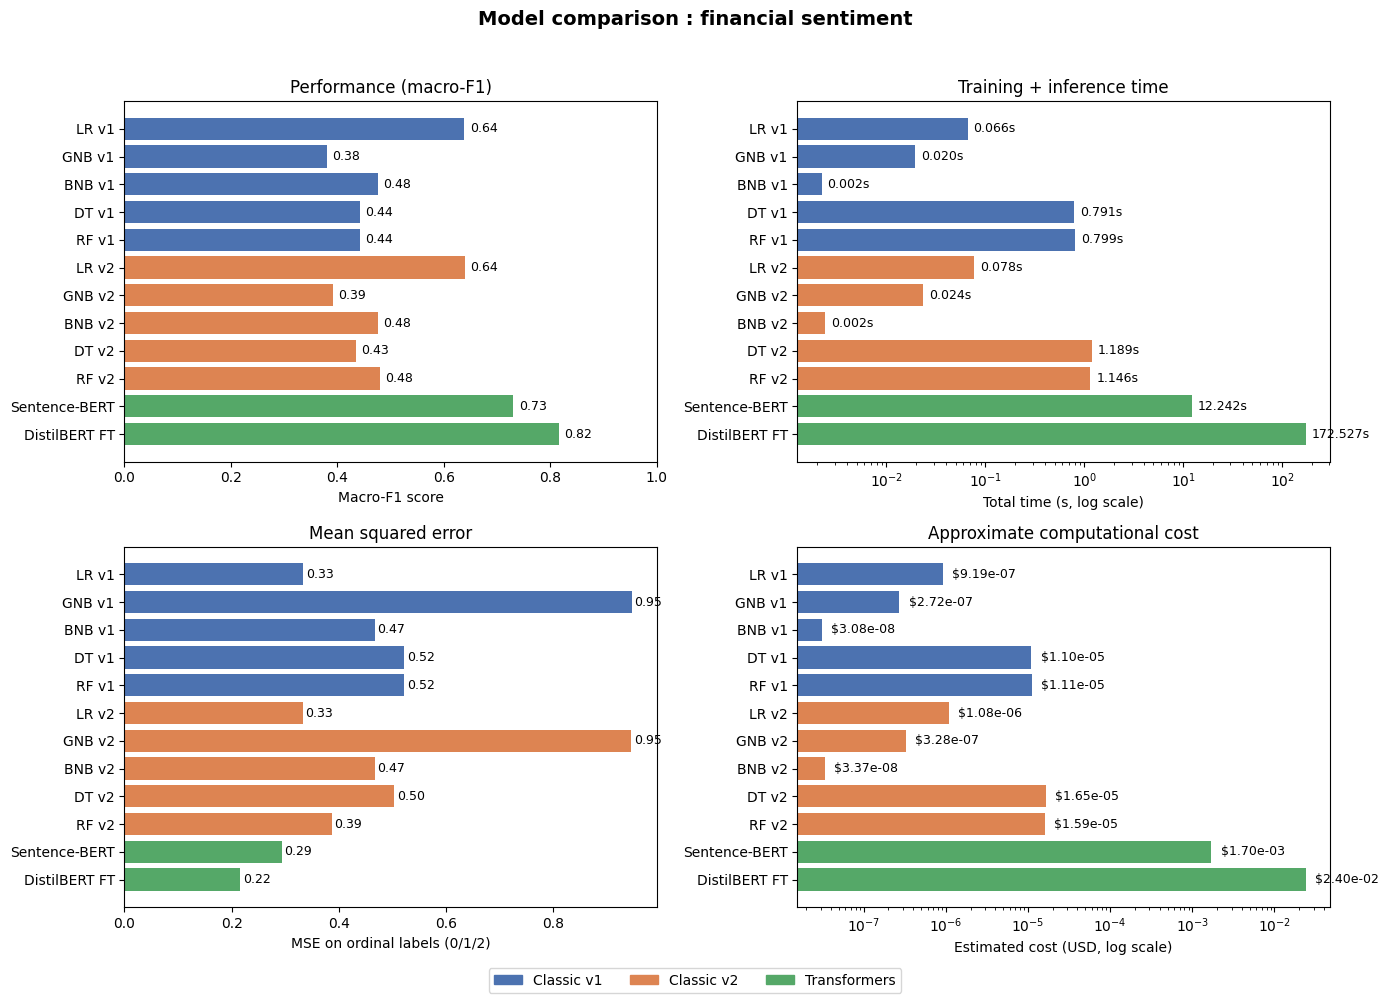

In [42]:
# Results collected dynamically from previous cells.
results = results_collected

# Indicative cloud pricing (USD / second)
PRICE_CPU = 0.05 / 3600
PRICE_GPU = 0.50 / 3600

for name, m in results.items():
    m["total_time"] = m["fit_time"] + m["pred_time"]
    m["cost_usd"]   = m["total_time"] * (PRICE_GPU if m["gpu"] else PRICE_CPU)

models     = list(results.keys())
macro_f1   = [results[m]["macro_f1"]   for m in models]
total_time = [results[m]["total_time"] for m in models]
mse        = [results[m]["mse"]        for m in models]
cost       = [results[m]["cost_usd"]   for m in models]

colors = []
for m in models:
    if "v1" in m:
        colors.append("#4C72B0")
    elif "v2" in m:
        colors.append("#DD8452")
    else:
        colors.append("#55A868")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model comparison : financial sentiment", fontsize=14, fontweight="bold")

# 1) Macro-F1
ax = axes[0, 0]
ax.barh(models, macro_f1, color=colors)
ax.set_xlabel("Macro-F1 score")
ax.set_title("Performance (macro-F1)")
ax.set_xlim(0, 1)
ax.invert_yaxis()
for i, v in enumerate(macro_f1):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)

# 2) Total time (log scale)
ax = axes[0, 1]
ax.barh(models, total_time, color=colors)
ax.set_xlabel("Total time (s, log scale)")
ax.set_xscale("log")
ax.set_title("Training + inference time")
ax.invert_yaxis()
for i, v in enumerate(total_time):
    ax.text(v * 1.15, i, f"{v:.3f}s", va="center", fontsize=9)

# 3) MSE
ax = axes[1, 0]
ax.barh(models, mse, color=colors)
ax.set_xlabel("MSE on ordinal labels (0/1/2)")
ax.set_title("Mean squared error")
ax.invert_yaxis()
for i, v in enumerate(mse):
    ax.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=9)

# 4) Cost (log scale)
ax = axes[1, 1]
ax.barh(models, cost, color=colors)
ax.set_xlabel("Estimated cost (USD, log scale)")
ax.set_xscale("log")
ax.set_title("Approximate computational cost")
ax.invert_yaxis()
for i, v in enumerate(cost):
    ax.text(v * 1.3, i, f"${v:.2e}", va="center", fontsize=9)

legend = [
    Patch(color="#4C72B0", label="Classic v1"),
    Patch(color="#DD8452", label="Classic v2"),
    Patch(color="#55A868", label="Transformers"),
]
fig.legend(handles=legend, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

## Results

Transformer-based models clearly dominate the other models. Fine-tuned DistilBERT reaches a macro-F1 of 0.82, followed by Sentence-BERT at 0.73. This gap is explained by the nature of the representations used: while TF-IDF treats words as independent features, transformers produce contextual embeddings that capture sentence meaning.

Among classical approaches, logistic regression stands out clearly from the rest, with a macro-F1 of 0.64 (v2) versus 0.39 to 0.48 for Naive Bayes, Decision Trees, and Random Forests. Moving from v1 to v2 (improved preprocessing) yields a light gain for LogReg (+0.03), but the effect is marginal or even negative for the other models, suggesting that the bottleneck lies in the model itself rather than in the features.

Gaussian, Random Forest, Decision Tree and Bernoulli have performances close to the random choice (33%).

MSE, computed on the ordinal label encoding (0 = negative, 1 = neutral, 2 = positive), reflects the severity of mistakes: confusing a negative with a positive (error of 2) is worse than confusing it with a neutral (error of 1). Transformers achieve the lowest MSE values (0.21 and 0.29), meaning they not only make fewer mistakes but also less severe ones. In contrast, GaussianNB v2 peaks at 0.95, it regularly makes extreme confusions between opposite classes.

Cost estimates are based on indicative cloud pricing of $0.05/h for CPU instances and $0.50/h for GPU instances, applied to the measured execution time.

The performance gap comes with a considerable cost gap. BernoulliNB runs in 2-3 milliseconds for a negligible cost (~$3 × 10⁻⁸), whereas fine-tuned DistilBERT requires 176 seconds and roughly $0.025 a factor of ~700,000× more expensive for around +0.18 macro-F1.
Logistic regression v2 occupies a particularly attractive sweet spot: 0.64 macro-F1 in 0.07 seconds for $10⁻⁶. It serves as an excellent baseline, easily deployable at scale when cost or latency are constrained.

## Limits

- Some words can loose their meanings with lemmatization and this was corrected with BERT.
- BERT Fined Tuned is pre-trained on Wikipedia and isn't specialized in finance terms.
- Our best models are the most expensive ones, if we train this model with more data, it can become expensive depending on the budget allowed for the project.
- The data is old (from before 2010), and the media may have changed the way they communicate.